## Statistics of 120 Dies

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import norm

In [ ]:
def simulate_dice_throws(n_dice: int, n_trials: int, n_sides: int = 6, seed: int | None = None):
    """
    Simulate throwing n_dice dice n_trials times.
    Returns an array of total sums for each throw.
    """
    rng = np.random.default_rng(seed)

    # Shape: (n_trials, n_dice)
    throws = rng.integers(1, n_sides + 1, size=(n_trials, n_dice))
    totals = throws.sum(axis=1)

    return totals


def compute_statistics(data: np.ndarray):
    """
    Compute sample mean and sample variance.
    """
    mean = np.mean(data)
    variance = np.var(data, ddof=1)  # sample variance
    return mean, variance


def plot_histogram_with_normal_fit(data: np.ndarray, n_dice: int, n_sides: int):
    """
    Plot histogram of simulated totals and overlay fitted normal distribution.
    """
    # Fit normal distribution to the simulated totals
    mu_fit, sigma_fit = norm.fit(data)

    # Use integer-centered bins for dice totals
    min_total = n_dice
    max_total = n_dice * n_sides
    bins = np.arange(min_total - 0.5, max_total + 1.5, 1)

    plt.figure(figsize=(10, 6))

    # Histogram normalized to density so PDF overlays correctly
    plt.hist(data, bins=bins, density=True, alpha=0.1, edgecolor="black", label="Simulated histogram")

    # x-grid for smooth fitted curve
    x = np.linspace(min_total, max_total, 500)
    pdf = norm.pdf(x, mu_fit, sigma_fit)
    plt.plot(x, pdf, linewidth=2, alpha=0.4, label=f"Normal fit: μ={mu_fit:.3f}, σ={sigma_fit:.3f}")

    plt.title(f"Histogram of total face value for {n_dice} dice")
    plt.xlabel("Total face value")
    plt.ylabel("Probability density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("probabilityManyDiceN{}.svg", format="svg", bbox_inches="tight")
    plt.show()


In [5]:
def main(n_dice: int = 120, n_trials: int = 100000, n_sides: int = 6, seed: int = 42):
    totals = simulate_dice_throws(n_dice, n_trials, n_sides, seed)
    mean, variance = compute_statistics(totals)

    # Theoretical values for comparison
    theoretical_mean = n_dice * (n_sides + 1) / 2
    theoretical_variance = n_dice * (n_sides**2 - 1) / 12

    print(f"Number of dice: {n_dice}")
    print(f"Number of trials: {n_trials}")
    print(f"Number of sides per die: {n_sides}")
    print()
    print(f"Simulated mean      = {mean:.6f}")
    print(f"Simulated variance  = {variance:.6f}")
    print()
    print(f"Theoretical mean    = {theoretical_mean:.6f}")
    print(f"Theoretical variance= {theoretical_variance:.6f}")

    plot_histogram_with_normal_fit(totals, n_dice, n_sides)



Number of dice: 120
Number of trials: 100000
Number of sides per die: 6

Simulated mean      = 419.977260
Simulated variance  = 351.784681

Theoretical mean    = 420.000000
Theoretical variance= 350.000000


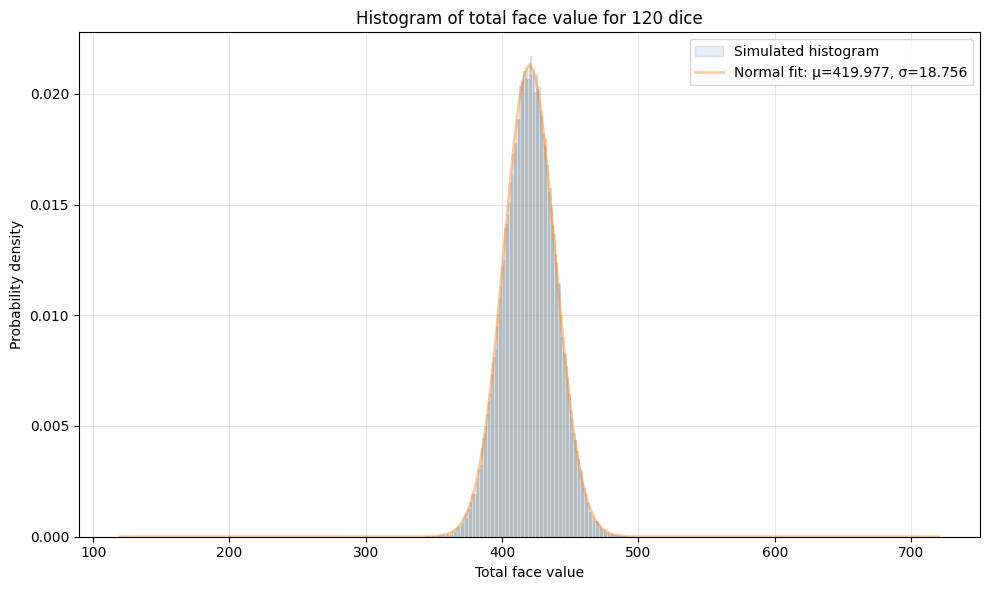

In [4]:
main()